In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Extreme Rays

In [5]:
flat_source, flat_target, inv, hl, f1, L, f2, da, a_max = np.loadtxt('datafin/input.csv', delimiter = ',')
source_text = "flat" if flat_source else "cylindrical"
target_text = "flat" if flat_target else "cylindrical"
inverted_text = "inverted" if inv else "not inverted"
print(f"{source_text} source -> {target_text} target, {inverted_text}")
print(f"half-length = {hl}, f1 = {f1}, L = {L}, f2 = {f2}, da = {da}, a_max = {a_max}")

cylindrical source -> cylindrical target, not inverted
half-length = 0.001, f1 = 1.0, L = 30.0, f2 = 1.0, da = 1e-06, a_max = 150.0


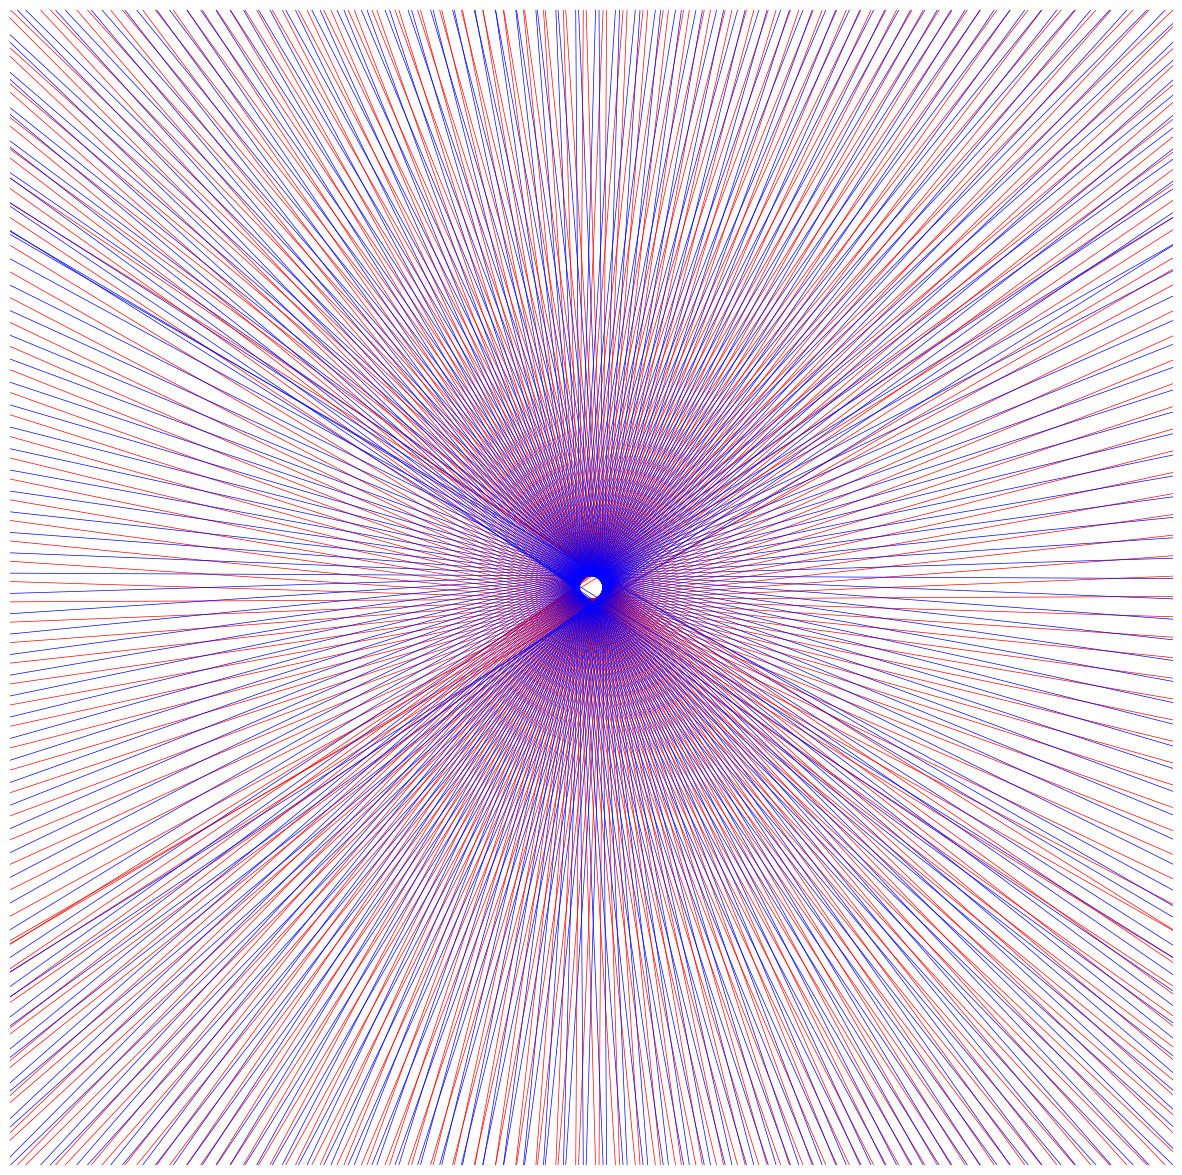

In [ ]:
fig, ax = plt.subplots(1, figsize = (15, 15))
extreme1 = np.loadtxt('datafin/extrdiff1.csv', delimiter = ',')
extreme2 = np.loadtxt('datafin/extrdiff2.csv', delimiter = ',')
for row in extreme1: ax.plot([row[0], row[2]], [row[1], row[3]], linewidth = 0.5, c = 'red')
for row in extreme2: ax.plot([row[0], row[2]], [row[1], row[3]], linewidth = 0.5, c = 'blue')
if flat_source and flat_target: ax.plot([0, 0], [-hl, hl], linewidth = 4, color = 'black', label = 'target')
elif not flat_source and flat_target: ax.plot([0, 0], [-hl, hl], linewidth = 4, color = 'black', label = 'target')

# 3. Create the inset axes
# [x, y, width, height] as a fraction of the main axes' dimensions
# Position the lower-left corner of the inset at (0.65, 0.65)
# Set width and height to 30% of the main axes' size
ax_inset = ax.inset_axes([0.65, 0.65, 0.3, 0.3]) # Top right corner placement

# 4. Plot data on the inset axes
ax_inset.plot(x_inset, y_inset, 'r-')
ax_inset.set_title('Inset Zoom')
ax_inset.set_xlim(8, 10)
ax_inset.set_ylim(-1, 1)
ax_inset.set_xticks([]) # Optional: hide ticks for cleaner look
ax_inset.set_yticks([])

# Optional: Draw lines to indicate the zoomed region in the main plot
ax.indicate_inset_zoom(ax_inset, edgecolor="black")

plt.axis('equal')
zoom = hl * 50
plt.axis([-zoom, zoom, -zoom, zoom])
plt.axis('off')
plt.show()

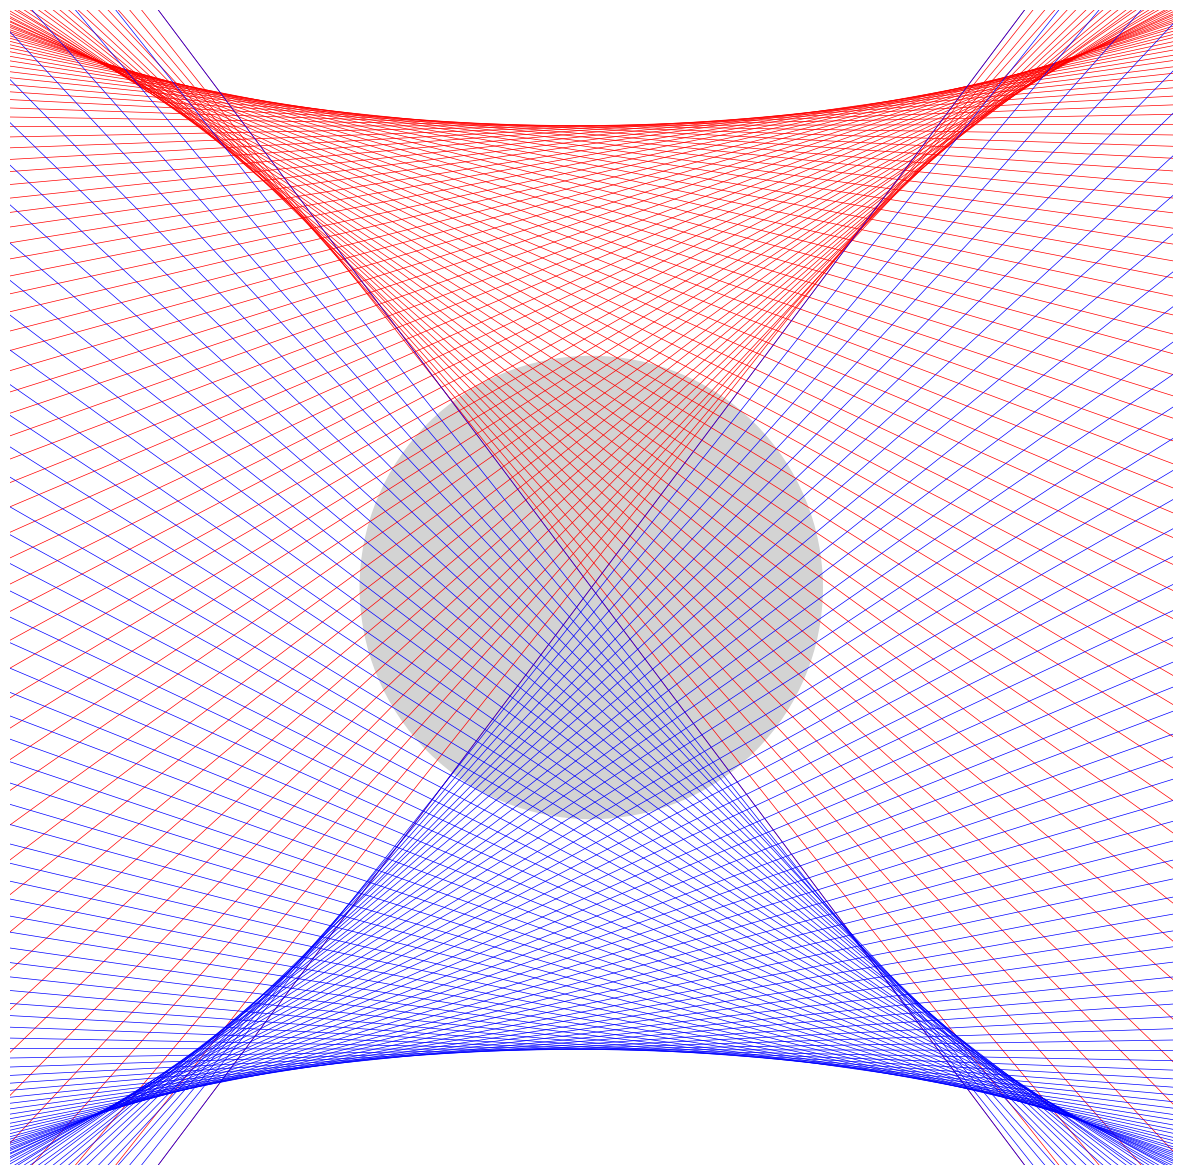

In [7]:
fig, ax = plt.subplots(1, figsize = (15, 15))

extrdiff1 = np.loadtxt('datafinpara/extrdiff1.csv', delimiter = ',')
extrdiff2 = np.loadtxt('datafinpara/extrdiff2.csv', delimiter = ',')
for row in extrdiff1: ax.plot([row[0], row[2]], [row[1], row[3]], linewidth = 0.5, c = 'red')
for row in extrdiff2: ax.plot([row[0], row[2]], [row[1], row[3]], linewidth = 0.5, c = 'blue')

if flat_source and flat_target: plt.plot([0, 0], [-hl, hl], linewidth = 4, color = 'black', label = 'target')
elif flat_source and not flat_target: plt.gca().add_patch(plt.Circle((0, 0), hl / np.pi, color = 'lightgrey', label = 'target'))
elif not flat_source and flat_target: plt.plot([0, 0], [-hl, hl], linewidth = 4, color = 'black', label = 'target')
elif not flat_source and not flat_target: plt.gca().add_patch(plt.Circle((0, 0), hl, color = 'lightgrey', label = 'target'))

Y = np.linspace(-5, 5, 100)
M1X = 1 / (4 * f1) * (Y ** 2) - L - f1
ax.scatter(M1X, Y, s = 10, c = 'blue', label = 'parabola 1')
M2X = -1 / (4 * f2) * (Y ** 2) + f2
ax.scatter(M2X, Y, s = 10, c = 'purple', label = 'parabola 2')

plt.axis('equal')
zoom = hl * 2.5 # 2, 20
plt.axis([-zoom, zoom, -zoom, zoom])
# plt.axis([-f1 - L - 2, f2 + 2, -5, 5])
plt.axis('off')
plt.show()